## Settings & imports

In [1]:
import numpy as np
import pandas as pd
import os
# import torch
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import string
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import csv
import pickle

In [2]:
object_name = 'Konstytucja_XRF' #Konstytucja_indicators / Konstytucja_prediction

book_name = 'app'

collapse = False

preprocessing_method = 'none'

In [3]:
data_path = {
            'Konstytucja_XRF' : '../data/XRF_data.csv'
            }

figures_path = {
                'Konstytucja_XRF' : '../figures/'
               }

results_path = {
                'Konstytucja_XRF': '../results/Konstytucja/'
                }

In [4]:
class_names_dict = {'podpis - Małachowski' : 'Małachowski - podpis',
                   'podpis -Małachowski' : 'Małachowski - podpis',
                   'podpis - Kossakowski' : 'Kossakowski - podpis',
                    'podpis - Jabłonowski' : 'Jabłonowski - podpis',
                    'podpis - Szydłowski' : 'Szydłowski - podpis',
                    'podpis - Kwilecki' : 'Kwilecki - podpis',      
                    'podpis - Plater': 'Plater - podpis', 
                    'podpis - Stroynowski' : 'Stroynowski - podpis', 
                    'podpis - Potocki' : 'Potocki - podpis',
                    'podpis - Zboiński' : 'Zboiński - podpis',
                    'podpis - Nowowiejski' : 'Nowowiejski - podpis',
                    'podpis - Radzicki' : 'Radzicki - podpis',
                    'podpis - Zabiełło' : 'Zabiełło - podpis',
                    'podpis - Puttkamer' : 'Puttkamer - podpis',
                    'podpis - Sapieha' : 'Sapieha - podpis',
                    'treść' : 'treść',
                    'poprawka' : 'poprawka',
                    'poprawka ': 'poprawka',
                    'papier' : 'papier',
                    'oblatowanie' : 'oblatowanie',
                    'komentarz' : 'komentarz',
                    'plama' : 'plama'
                    }

elements = ['S', 'K', 'Mn', 'Cu', 'Zn']

non_signatures = ['treść', 'poprawka', 'oblatowanie', 'komentarz', 'plama']

## Loading the data

In [5]:
if object_name == 'Konstytucja_XRF':
    inks_xrf = pd.read_csv(data_path[object_name], delimiter=',')

## Preprocessing

In [6]:
inks_xrf.columns = ['S', 'K', 'Mn', 'Cu', 'Zn', 'Code', 'Class name', 'Book name']
inks_xrf['Class name'] = inks_xrf['Class name'].map(class_names_dict)
inks_xrf['Code'] = inks_xrf['Code'].apply(lambda x: x[:-1] if str.isalpha(x[-1]) else x)
inks_xrf.reset_index(drop=True, inplace=True)

### Dividing to APP, ASC and ML

In [7]:
df = inks_xrf
df_app = inks_xrf[inks_xrf['Book name']=='APP']
df_asc = inks_xrf[inks_xrf['Book name']=='ASC']
df_ml = inks_xrf[inks_xrf['Book name']=='ML']

if book_name == 'app':
    df = df_app
elif book_name == 'asc':
    df = df_asc
elif book_name == 'ml':
    df = df_ml
elif book_name == 'all':
    pass

### Collapsing 13 copies to one data point (optional)

In [8]:
#TO DO: FINISH THIS CASE
if collapse:
    pass

### Converting to np.array

In [9]:
X = np.array(df[elements].values)

### Normalizing / taking logarithm

In [10]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [11]:
if preprocessing_method == 'normalization':

    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X = adjusted_log_transform(X)
    
elif preprocessing_method == 'none':
    
    pass

## Ground truth

In [12]:
#TO DO: FINISH
if collapse:
    pass
else:
    class_df = df[['Code', 'Class name']]

### Analysis

In [13]:
#TO DO: FINISH
if collapse:
    pass
else:
    y = class_df['Class name']
    y = [str(y) for y in y]
    rest_indices = class_df['Class name'].apply(lambda x: x in non_signatures)
    rest_indices = rest_indices[rest_indices].index
    names_indices = set(range(class_df.shape[0])).difference(set(rest_indices))

### PCA

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [15]:
#%matplotlib widget

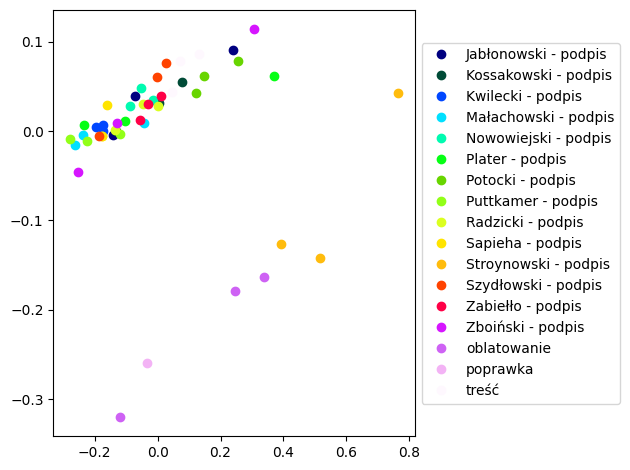

In [16]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_pca.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION ALL 13

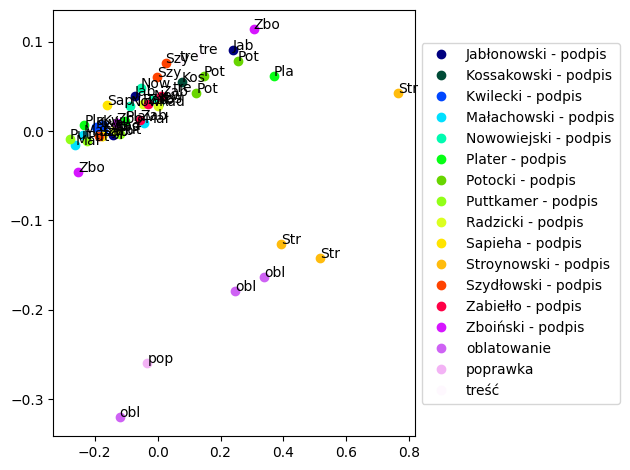

In [17]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_pca.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:3], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION ALL 15

### tSNE

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

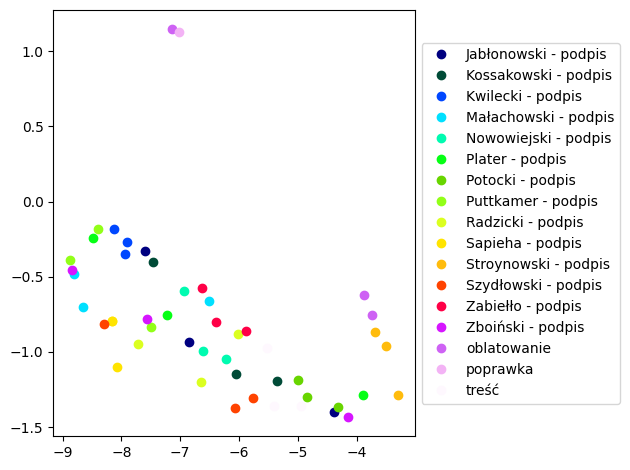

In [19]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_tsne.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION ALL 13

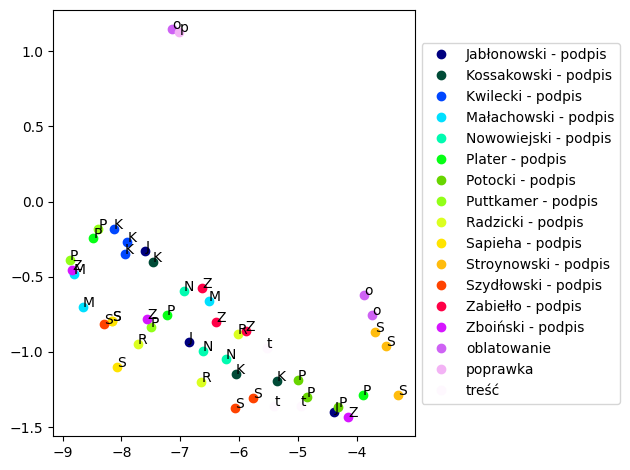

In [20]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_tsne.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION ALL 13

- drawing random records from the same group?

## Clustering

In [24]:
from sklearn import cluster

In [25]:
#TO DO
if collapse:
    pass
else:
    y = class_df['Class name']
    y = [str(y) for y in y]

In [26]:
cluster_only_names = False
if cluster_only_names:
    X_to_cluster = X[names_indices,:]
    y_to_plot = [y[ind] for ind in names_indices]
else:
    X_to_cluster = X
    y_to_plot = y

In [27]:
nr_of_clusters = 20
clustering = cluster.AgglomerativeClustering(n_clusters=nr_of_clusters).fit(X_to_cluster)
#clustering = cluster.SpectralClustering(n_clusters=nr_of_clusters).fit(X_to_cluster)
#clustering = cluster.DBSCAN().fit(X_to_cluster)

#clustering.labels_

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_to_cluster)

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_to_cluster)

In [29]:
#%matplotlib notebook

In [30]:
clustering.labels_.shape

(49,)

In [31]:
class_df['Code']

0        APP0
1        APP0
2        APP0
3       APP10
4       APP10
5       APP10
6       APP11
7       APP11
8       APP11
9       APP12
10      APP12
11      APP12
12      APP13
13      APP13
14      APP13
15      APP14
16      APP14
17      APP14
18    APP15C2
19      APP16
20      APP16
21      APP16
22       APP1
23       APP1
24       APP1
25       APP2
26       APP2
27       APP2
28       APP3
29       APP3
30       APP3
31       APP4
32       APP4
33       APP4
34       APP5
35       APP5
36       APP5
37       APP6
38       APP6
39       APP6
40       APP7
41       APP7
42       APP7
43       APP8
44       APP8
45       APP8
46       APP9
47       APP9
48       APP9
Name: Code, dtype: object

In [32]:
set(y_to_plot)

{'Jabłonowski - podpis',
 'Kossakowski - podpis',
 'Kwilecki - podpis',
 'Małachowski - podpis',
 'Nowowiejski - podpis',
 'Plater - podpis',
 'Potocki - podpis',
 'Puttkamer - podpis',
 'Radzicki - podpis',
 'Sapieha - podpis',
 'Stroynowski - podpis',
 'Szydłowski - podpis',
 'Zabiełło - podpis',
 'Zboiński - podpis',
 'oblatowanie',
 'poprawka',
 'treść'}

In [33]:
list(reversed(sorted(set(y_to_plot))))

['treść',
 'poprawka',
 'oblatowanie',
 'Zboiński - podpis',
 'Zabiełło - podpis',
 'Szydłowski - podpis',
 'Stroynowski - podpis',
 'Sapieha - podpis',
 'Radzicki - podpis',
 'Puttkamer - podpis',
 'Potocki - podpis',
 'Plater - podpis',
 'Nowowiejski - podpis',
 'Małachowski - podpis',
 'Kwilecki - podpis',
 'Kossakowski - podpis',
 'Jabłonowski - podpis']

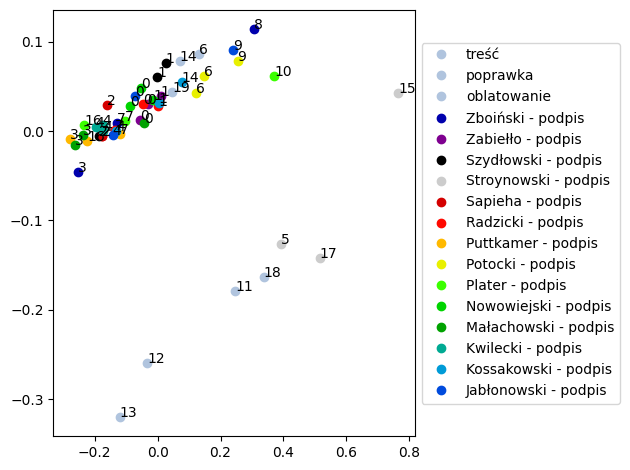

<Figure size 1000x700 with 0 Axes>

In [34]:
annotate = True

unidentified = ['komentarz', 'nan', 'oblatowanie', 'papier', 'poprawka', 'treść']
names_set = set(y_to_plot).difference(set(unidentified))


if collapse:
    color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
else:
    color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
    
for label_nr, label in enumerate(reversed(sorted(set(y_to_plot)))):
    if label in unidentified:
        x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_pca_0, x_pca_1, 'o', label = label, color='lightsteelblue')
    else:
        x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_pca_0, x_pca_1, 'o', label = label, color=color[label_nr-len(unidentified)])
    
if annotate:
    for i in range(X_pca.shape[0]):
        if isinstance(y_to_plot[i], float):
            pass
        else:
            #version with cluster numbers
            plt.annotate(clustering.labels_[i], (X_pca[i, 0], X_pca[i,1]))
            #version with book name
            #plt.annotate(class_df['Code'][i], (X_pca[i, 0], X_pca[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams['figure.figsize'] = [10, 7]

plt.tight_layout()
plt.show()

plt.savefig('../figures/clustering_PCA_book_' + str(book_name) + '_annotate_' + str(annotate))

#PREDICTION ALL 13

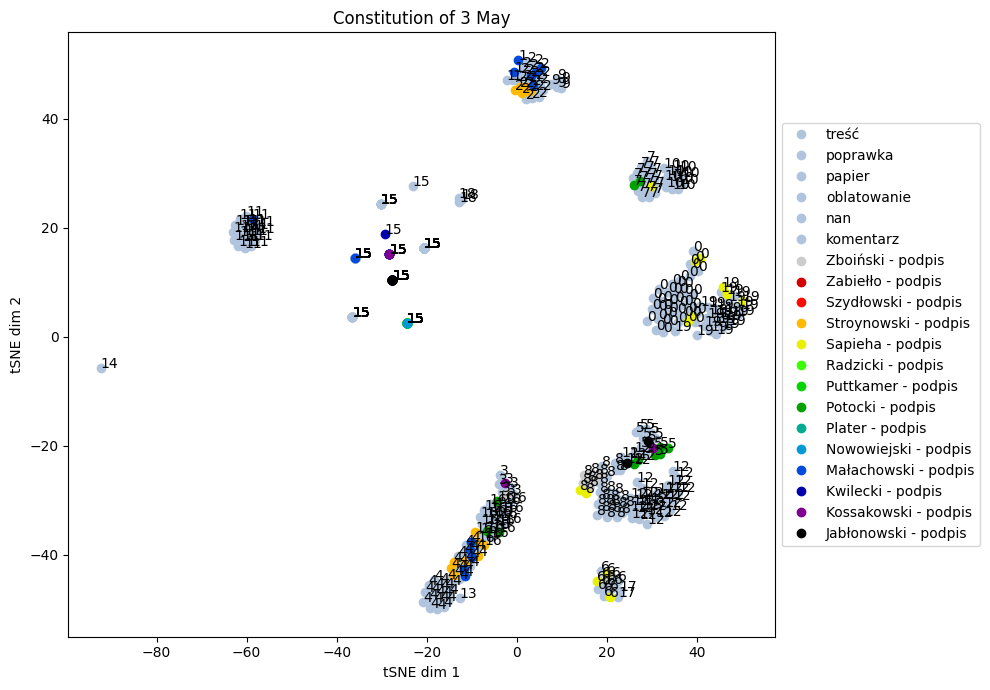

In [34]:
annotate = True

unidentified = ['komentarz', 'nan', 'oblatowanie', 'papier', 'poprawka', 'treść']
names_set = set(y_to_plot).difference(set(unidentified))

if collapse:
    color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
else:
    color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
    
for label_nr, label in enumerate(reversed(sorted(set(y_to_plot)))):
    if label in unidentified:
        x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_tsne_0, x_tsne_1, 'o', label = label, color='lightsteelblue')
#     elif label in ['nan']:
#         pass
    else:
        x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_tsne_0, x_tsne_1, 'o', label = label, color=color[label_nr-len(unidentified)])
    
if annotate:
    for i in range(X_tsne.shape[0]):
        if isinstance(y_to_plot[i], float):
            pass
        else:
            plt.annotate(clustering.labels_[i], (X_tsne[i, 0], X_tsne[i,1]))
            
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams['figure.figsize'] = [10, 7]

plt.xlabel('tSNE dim 1')
plt.ylabel('tSNE dim 2')
plt.title('Constitution of 3 May')

plt.tight_layout()
plt.show()

#plt.savefig('../figures/clustering_tSNE_book_' + str(book_name) + '_annotate_' + str(annotate))

#PREDICTION ALL 13

In [35]:
clusters = []
for i in range(nr_of_clusters):
    clust = [(int(el1), el2) for el1, el2 in list(zip(clustering.labels_, y_to_plot)) if el1==i]
    clusters.append(clust)

In [36]:
clusters

[[(0, 'Małachowski - podpis'),
  (0, 'Radzicki - podpis'),
  (0, 'Zabiełło - podpis'),
  (0, 'Zabiełło - podpis'),
  (0, 'Jabłonowski - podpis'),
  (0, 'Nowowiejski - podpis'),
  (0, 'Nowowiejski - podpis')],
 [(1, 'Radzicki - podpis'),
  (1, 'Zabiełło - podpis'),
  (1, 'Kossakowski - podpis'),
  (1, 'Szydłowski - podpis'),
  (1, 'Szydłowski - podpis'),
  (1, 'Nowowiejski - podpis')],
 [(2, 'Sapieha - podpis'),
  (2, 'Sapieha - podpis'),
  (2, 'Sapieha - podpis'),
  (2, 'Szydłowski - podpis')],
 [(3, 'Małachowski - podpis'),
  (3, 'Małachowski - podpis'),
  (3, 'Puttkamer - podpis'),
  (3, 'Zboiński - podpis')],
 [(4, 'Kossakowski - podpis'),
  (4, 'Jabłonowski - podpis'),
  (4, 'Kwilecki - podpis'),
  (4, 'Kwilecki - podpis'),
  (4, 'Kwilecki - podpis')],
 [(5, 'Stroynowski - podpis')],
 [(6, 'treść'), (6, 'Potocki - podpis'), (6, 'Potocki - podpis')],
 [(7, 'Radzicki - podpis'),
  (7, 'Puttkamer - podpis'),
  (7, 'Plater - podpis'),
  (7, 'Zboiński - podpis')],
 [(8, 'Zboiński - podp

In [38]:
with open(results_path[object_name] + 'clustering_of_XRF_data_number_of_clusters' + str(nr_of_clusters) + '.pkl', 'wb') as f:
    pickle.dump(clusters, f)

In [73]:
# EUCLIDEAN
# bad: 0, 2, 7, 8
# medium: 3, 6, 9, 10, 11
# good: 1, 4, 5, 12

# COSINE
# bad: 1, 4, 5, 6, 7
# medium: 3
# good: 0, 2

clusters

[[(0, 'poprawka'),
  (0, 'poprawka'),
  (0, 'treść'),
  (0, 'treść'),
  (0, 'poprawka'),
  (0, 'poprawka'),
  (0, 'poprawka')],
 [(1, 'nan'),
  (1, 'treść'),
  (1, 'treść'),
  (1, 'treść'),
  (1, 'poprawka'),
  (1, 'poprawka'),
  (1, 'poprawka'),
  (1, 'poprawka')],
 [(2, 'Radzicki'), (2, 'nan'), (2, 'treść'), (2, 'poprawka')],
 [(3, 'Nowowiejski'), (3, 'poprawka'), (3, 'poprawka'), (3, 'poprawka')],
 [(4, 'poprawka'), (4, 'poprawka')],
 [(5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka')],
 [(6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść')],
 [(7, 'Nowowiejski'), (7, 'nan')],
 [(8, 'treść'), (8, 'treść'), (8, 'treść')],
 [(9, 'treść'), (9, 'treść'), (9, 'treść')],
 [(10, 'treść'), (10, 'treść')],
 [(11, 'poprawka')],
 [(12, 'poprawka'),
  (12, 'poprawka'),
  (12, 'nan'),
  (12, 'nan'),
  (12, 'treść'),
  (12, 'treść'),
  (12, 'komen

In [ ]:
ms = cluster.MeanShift(banwidth=banwidth, bin_seeding=True)
two_means = cluster.MiniBatchKMeans(
    n_clusters=params["n_clusters"],
    random_state=params["random_state"],
)
ward = cluster.AgglomerativeClustering(
    n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
)
spectral = cluster.SpectralClustering(
    n_clusters=params["n_clusters"],
    eigen_solver="arpack",
    affinity="nearest_neighbors",
    random_state=params["random_state"],
)
dbscan = cluster.DBSCAN(eps=params["eps"])
hdbscan = cluster.HDBSCAN(
    min_samples=params["hdbscan_min_samples"],
    min_cluster_size=params["hdbscan_min_cluster_size"],
    allow_single_cluster=params["allow_single_cluster"],
)
optics = cluster.OPTICS(
    min_samples=params["min_samples"],
    xi=params["xi"],
    min_cluster_size=params["min_cluster_size"],
)
affinity_propagation = cluster.AffinityPropagation(
    damping=params["damping"],
    preference=params["preference"],
    random_state=params["random_state"],
)
average_linkage = cluster.AgglomerativeClustering(
    linkage="average",
    metric="cityblock",
    n_clusters=params["n_clusters"],
    connectivity=connectivity,
)
birch = cluster.Birch(n_clusters=params["n_clusters"])
gmm = mixture.GaussianMixture(
    n_components=params["n_clusters"],
    covariance_type="full",
    random_state=params["random_state"],
)

clustering_algorithms = (
    ("MiniBatch\nKMeans", two_means),
    ("Affinity\nPropagation", affinity_propagation),
    ("MeanShift", ms),
    ("Spectral\nClustering", spectral),
    ("Ward", ward),
    ("Agglomerative\nClustering", average_linkage),
    ("DBSCAN", dbscan),
    ("HDBSCAN", hdbscan),
    ("OPTICS", optics),
    ("BIRCH", birch),
    ("Gaussian\nMixture", gmm),
)